In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X = df.drop(columns=['petal length (cm)'])
y = df['petal length (cm)']

X = X.values
y = y.values


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,)


In [5]:
# 5. Feature Scaling
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

y_train_scaled = sc_y.fit_transform(y_train.reshape(-1,1)).ravel()


In [6]:
model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
model.fit(X_train_scaled, y_train_scaled)


,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [7]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()


In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")


Model Performance:
MAE: 0.2592
MSE: 0.1144
R2 Score: 0.9651


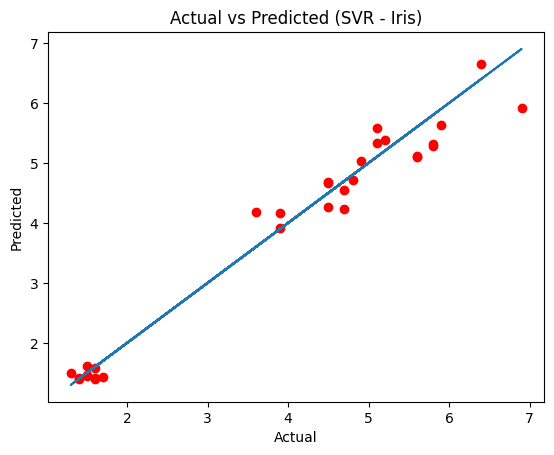

In [9]:
plt.scatter(y_test, y_pred,color = 'red')
plt.plot(y_test, y_test)

plt.title("Actual vs Predicted (SVR - Iris)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


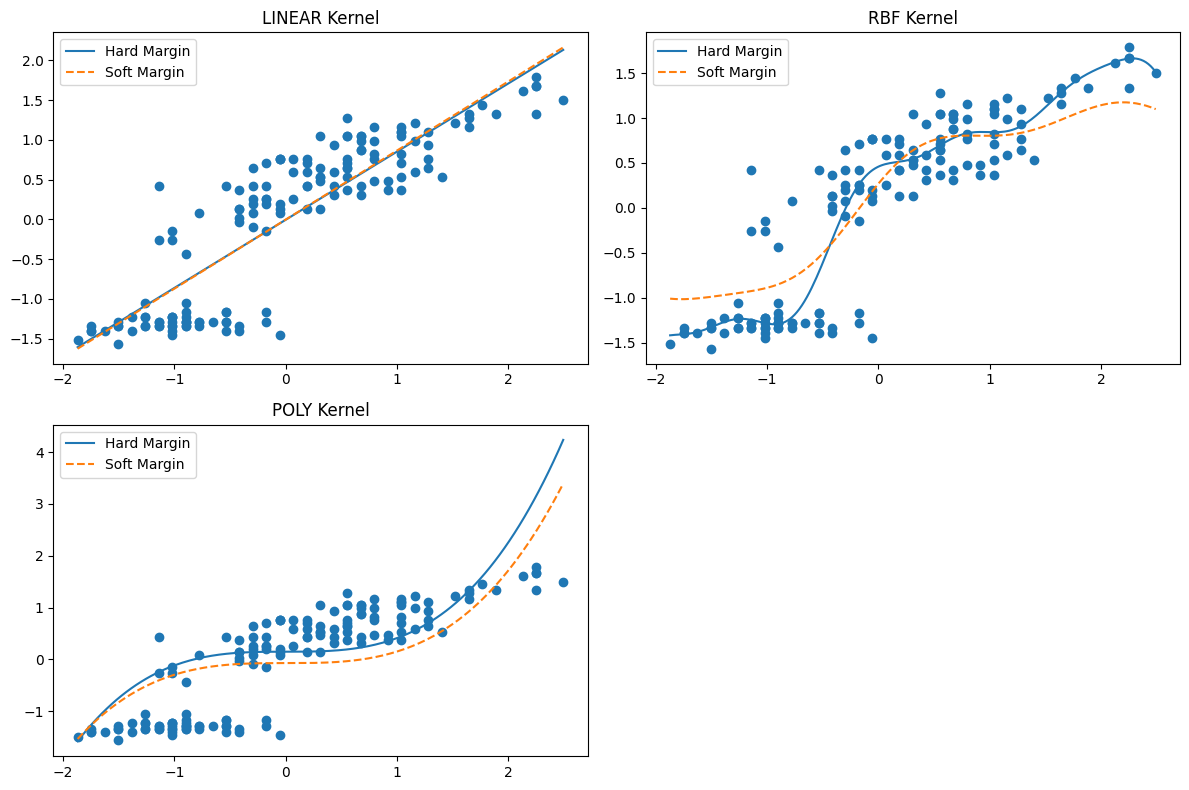

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, 0].reshape(-1, 1)   # use single feature for visualization
y = iris.data[:, 2]                  # target = petal length

sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.reshape(-1,1)).ravel()

X_grid = np.linspace(X_scaled.min(), X_scaled.max(), 200).reshape(-1,1)

kernels = ['linear', 'rbf', 'poly']

plt.figure(figsize=(12,8))

for i, kernel in enumerate(kernels, 1):
    
    svr_hard = SVR(kernel=kernel, C=1000, epsilon=0.01)
    svr_hard.fit(X_scaled, y_scaled)
    y_hard = svr_hard.predict(X_grid)
    
    svr_soft = SVR(kernel=kernel, C=1, epsilon=0.5)
    svr_soft.fit(X_scaled, y_scaled)
    y_soft = svr_soft.predict(X_grid)
    
    plt.subplot(2, 2, i)
    plt.scatter(X_scaled, y_scaled)
    plt.plot(X_grid, y_hard, label="Hard Margin")
    plt.plot(X_grid, y_soft, linestyle='dashed', label="Soft Margin")
    
    plt.title(f"{kernel.upper()} Kernel")
    plt.legend()

plt.tight_layout()
plt.show()

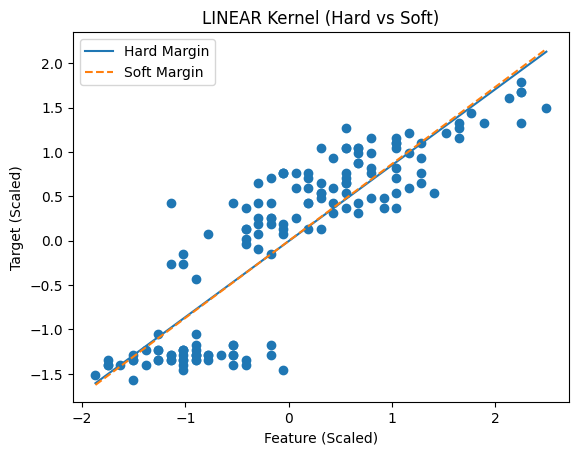

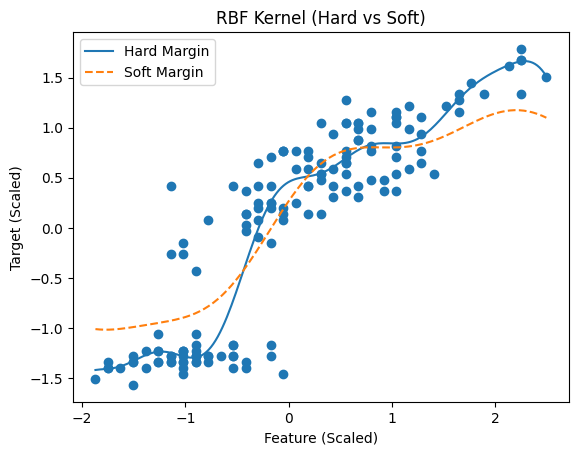

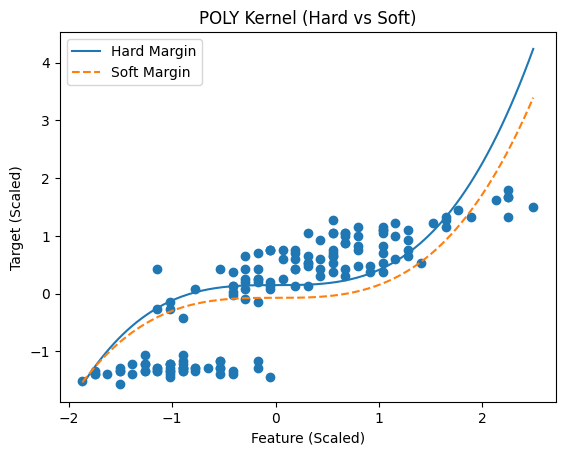

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:, 0].reshape(-1, 1)   # single feature
y = iris.data[:, 2]                  # target

sc_X = StandardScaler()
sc_y = StandardScaler()

X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y.reshape(-1,1)).ravel()

X_grid = np.linspace(X_scaled.min(), X_scaled.max(), 200).reshape(-1,1)

kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:
    
    svr_hard = SVR(kernel=kernel, C=1000, epsilon=0.01)
    svr_hard.fit(X_scaled, y_scaled)
    y_hard = svr_hard.predict(X_grid)
    
    svr_soft = SVR(kernel=kernel, C=1, epsilon=0.5)
    svr_soft.fit(X_scaled, y_scaled)
    y_soft = svr_soft.predict(X_grid)
    
    plt.figure()
    
    plt.scatter(X_scaled, y_scaled)
    plt.plot(X_grid, y_hard, label='Hard Margin')
    plt.plot(X_grid, y_soft, linestyle='dashed', label='Soft Margin')
    
    plt.title(f"{kernel.upper()} Kernel (Hard vs Soft)")
    plt.xlabel("Feature (Scaled)")
    plt.ylabel("Target (Scaled)")
    plt.legend()
    
    plt.show()